# Phase 4 — Modelling
## Air Quality Intelligence Platform

We train two parallel tracks of models:

**Track A — Classification:** Predict the AQI category (Good / Moderate / Poor / Very Poor)
from sensor readings, weather, and engineered time/lag/rolling features.

**Track B — Regression:** Predict the exact NO₂ concentration (µg/m³) for the next hour.

For each track we train:
1. A **baseline** model (trivial predictor — sets the floor)
2. A **Random Forest** (parallel ensemble of decision trees)
3. An **XGBoost** model (sequential boosted ensemble)

The best model from each track is saved to disk for Phase 5 (SHAP interpretability)
and Phase 6 (Streamlit dashboard).

In [1]:
# ── Standard library ──────────────────────────────────────────────
import os
import json
import warnings

# ── Data manipulation ─────────────────────────────────────────────
import pandas as pd
import numpy as np

# ── Visualisation ─────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

# ── Scikit-learn: models and metrics ─────────────────────────────
from sklearn.dummy      import DummyClassifier, DummyRegressor
# DummyClassifier/DummyRegressor are scikit-learn's built-in baseline
# models. DummyClassifier(strategy="most_frequent") always predicts
# the class that appears most often in training data.

from sklearn.ensemble   import RandomForestClassifier, RandomForestRegressor
# RandomForest builds N independent decision trees on random subsets
# of the data and features, then averages their predictions.
# This "bagging" approach reduces variance without increasing bias.

from sklearn.metrics    import (
    accuracy_score,        # Fraction of correctly classified samples
    f1_score,              # Harmonic mean of precision and recall — better than
                           # accuracy for imbalanced classes
    classification_report, # Full per-class precision, recall, F1 table
    confusion_matrix,      # Matrix showing predicted vs actual class counts
    mean_squared_error,    # Average squared prediction error (regression)
    mean_absolute_error,   # Average absolute prediction error (regression)
    r2_score               # R² — fraction of variance explained by the model
                           # R²=1 is perfect, R²=0 means model = mean predictor
)
import joblib
# joblib: saves and loads Python objects (models, scalers) to .pkl files

# ── XGBoost ───────────────────────────────────────────────────────
from xgboost import XGBClassifier, XGBRegressor
# XGBoost (eXtreme Gradient Boosting) builds trees sequentially.
# Each new tree focuses on correcting the errors of all previous trees.
# This "boosting" approach often achieves higher accuracy than Random Forest
# but requires more careful hyperparameter tuning.

# ── Settings ──────────────────────────────────────────────────────
warnings.filterwarnings("ignore")
plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.float_format", "{:.4f}".format)

os.makedirs("../models", exist_ok=True)
# Create a models/ folder to store saved model .pkl files

os.makedirs("../outputs", exist_ok=True)

RANDOM_STATE = 42
# Using a fixed random seed makes results reproducible.
# Every model that has randomness (Random Forest, XGBoost) accepts
# random_state=RANDOM_STATE to produce the same result each run.

print("All imports successful ✓")
print(f"  scikit-learn and XGBoost ready")

All imports successful ✓
  scikit-learn and XGBoost ready


In [2]:
# ── Load the split DataFrames ─────────────────────────────────────
df_train = pd.read_csv("../data/processed/train.csv")
df_val   = pd.read_csv("../data/processed/val.csv")
df_test  = pd.read_csv("../data/processed/test.csv")

# Re-parse DateTime in each split
for df in [df_train, df_val, df_test]:
    df["DateTime"] = pd.to_datetime(df["DateTime"], errors="coerce")

# ── Load the feature column list ──────────────────────────────────
with open("../data/processed/feature_cols.json", "r") as f:
    FEATURE_COLS = json.load(f)
# json.load() reads a JSON file back into a Python object (here: a list).
# This guarantees we use EXACTLY the same features and order as Phase 3.

# ── Load the fitted scaler ────────────────────────────────────────
scaler = joblib.load("../data/processed/scaler.pkl")
# joblib.load() reconstructs the fitted StandardScaler from disk.
# The scaler already "knows" the mean and std from training data.

# ── Define targets ────────────────────────────────────────────────
TARGET_CLASS = "AQI_category"   # Classification target (0, 1, 2, 3)
TARGET_REG   = "NO2(GT)"        # Regression target (continuous µg/m³)

# ── Extract X and y matrices ──────────────────────────────────────
# Classification
X_train = df_train[FEATURE_COLS]
y_train_cls = df_train[TARGET_CLASS].astype(int)
# .astype(int) ensures the target is integer (0,1,2,3), not float.
# Some classifiers require integer labels.

X_val   = df_val[FEATURE_COLS]
y_val_cls = df_val[TARGET_CLASS].astype(int)

X_test  = df_test[FEATURE_COLS]
y_test_cls = df_test[TARGET_CLASS].astype(int)

# Regression
y_train_reg = df_train[TARGET_REG]
y_val_reg   = df_val[TARGET_REG]
y_test_reg  = df_test[TARGET_REG]

# ── Apply scaling ─────────────────────────────────────────────────
# Use the scaler fitted in Phase 3 — do NOT refit here.
X_train_sc = scaler.transform(X_train)
X_val_sc   = scaler.transform(X_val)
X_test_sc  = scaler.transform(X_test)

print("Data loaded and split verified:")
print(f"  X_train: {X_train.shape}  |  y_train_cls distribution: {dict(y_train_cls.value_counts().sort_index())}")
print(f"  X_val:   {X_val.shape}")
print(f"  X_test:  {X_test.shape}")
print(f"\n  Features: {len(FEATURE_COLS)}")
print(f"  Target (classification): {TARGET_CLASS}")
print(f"  Target (regression):     {TARGET_REG}")

Data loaded and split verified:
  X_train: (2501, 46)  |  y_train_cls distribution: {0: np.int64(130), 1: np.int64(1060), 2: np.int64(1297), 3: np.int64(14)}
  X_val:   (536, 46)
  X_test:  (536, 46)

  Features: 46
  Target (classification): AQI_category
  Target (regression):     NO2(GT)


In [3]:
# We define these once here and reuse them for every model.
# Keeping evaluation logic in functions avoids copy-pasting code
# and ensures every model is evaluated identically.

AQI_LABELS = ["Good", "Moderate", "Poor", "Very Poor"]

def evaluate_classifier(model, X, y_true, split_name="Validation"):
    """
    Evaluates a trained classifier on the given data split.
    Prints a full report and returns a metrics dictionary.

    Args:
        model:      A fitted scikit-learn compatible classifier
        X:          Feature matrix (numpy array or DataFrame)
        y_true:     True class labels
        split_name: Label for printing ("Validation" or "Test")

    Returns:
        dict with accuracy, f1_macro, f1_weighted
    """
    y_pred = model.predict(X)
    # .predict() runs the model on X and returns predicted class labels.

    acc  = accuracy_score(y_true, y_pred)
    # Accuracy = correct predictions / total predictions.
    # Simple but misleading with imbalanced classes.

    f1_macro    = f1_score(y_true, y_pred, average="macro",    zero_division=0)
    f1_weighted = f1_score(y_true, y_pred, average="weighted", zero_division=0)
    # F1 = 2 × (precision × recall) / (precision + recall)
    # It balances two competing concerns:
    #   Precision: of all predicted "Poor", how many were actually "Poor"?
    #   Recall:    of all actual "Poor" cases, how many did we catch?
    #
    # average="macro": compute F1 for each class separately, then take
    #   the unweighted mean — treats all classes equally regardless of size.
    # average="weighted": weight each class's F1 by how many samples it has
    #   — better reflects overall model performance with imbalanced classes.
    # zero_division=0: if a class has no predictions, return 0 instead of error.

    print(f"\n{'─'*50}")
    print(f"  {split_name} results")
    print(f"{'─'*50}")
    print(f"  Accuracy:    {acc:.4f}")
    print(f"  F1 (macro):  {f1_macro:.4f}")
    print(f"  F1 (weighted): {f1_weighted:.4f}")
    print(f"\n  Classification report:")
    print(classification_report(
        y_true, y_pred,
        target_names=AQI_LABELS[:len(np.unique(y_true))],
        zero_division=0
    ))
    # classification_report() prints a table with per-class precision,
    # recall, F1, and support (number of true examples) for each class.

    return {"accuracy": acc, "f1_macro": f1_macro, "f1_weighted": f1_weighted}


def evaluate_regressor(model, X, y_true, split_name="Validation"):
    """
    Evaluates a trained regressor on the given data split.

    Args:
        model:      A fitted scikit-learn compatible regressor
        X:          Feature matrix
        y_true:     True continuous target values
        split_name: Label for printing

    Returns:
        dict with rmse, mae, r2
    """
    y_pred = model.predict(X)

    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    # RMSE = Root Mean Squared Error.
    # Penalises large errors more than small ones (because errors are squared).
    # In the same units as the target (µg/m³ here).
    # Lower is better. A RMSE of 10 µg/m³ means our predictions are
    # off by about 10 µg/m³ on average (with large errors weighted more).

    mae  = mean_absolute_error(y_true, y_pred)
    # MAE = Mean Absolute Error.
    # Average of absolute differences — more interpretable than RMSE.
    # Also in units of µg/m³. Less sensitive to outliers than RMSE.

    r2   = r2_score(y_true, y_pred)
    # R² (R-squared) = coefficient of determination.
    # Measures what fraction of the variance in y the model explains.
    # R²=1: perfect. R²=0: model = mean predictor. R²<0: worse than mean.

    print(f"\n{'─'*50}")
    print(f"  {split_name} results")
    print(f"{'─'*50}")
    print(f"  RMSE: {rmse:.4f} µg/m³")
    print(f"  MAE:  {mae:.4f} µg/m³")
    print(f"  R²:   {r2:.4f}")

    return {"rmse": rmse, "mae": mae, "r2": r2}


print("Evaluation helper functions defined ✓")

Evaluation helper functions defined ✓


---
## Track A — Classification: Predicting AQI Category

### The class imbalance problem

Our dataset has many more "Good" and "Moderate" readings than "Poor" or
"Very Poor" ones (as we saw in Phase 3). A naive model will simply learn
to always predict "Moderate" and get decent accuracy — but completely fail
to detect the dangerous "Poor" and "Very Poor" cases that actually matter.

**Solution: `class_weight="balanced"`**

This tells scikit-learn to automatically weight each class inversely
proportional to its frequency. Rare classes (Poor, Very Poor) get higher
weights, so the model is penalised more for misclassifying them.

In XGBoost, the equivalent parameter is `scale_pos_weight` for binary
classification, and we use `sample_weight` in the fit call for multiclass.

In [4]:
from sklearn.utils.class_weight import compute_class_weight
# compute_class_weight() calculates the inverse-frequency weight for each class.
# This is what class_weight="balanced" does internally in sklearn estimators.

classes = np.unique(y_train_cls)
# np.unique() returns the sorted array of unique values: [0, 1, 2, 3]

class_weights_array = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y_train_cls
)
# "balanced" mode: weight = n_samples / (n_classes × n_samples_in_class)
# A class with half as many samples gets twice the weight.

class_weight_dict = dict(zip(classes, class_weights_array))
# zip(classes, weights) pairs each class label with its weight.
# dict() converts the pairs to a dictionary: {0: 1.2, 1: 0.8, 2: 3.1, 3: 8.4}

print("Class weights (balanced):")
aqi_names = {0: "Good", 1: "Moderate", 2: "Poor", 3: "Very Poor"}
for cls, weight in class_weight_dict.items():
    count = (y_train_cls == cls).sum()
    print(f"  Class {cls} ({aqi_names[cls]:10s}): weight={weight:.3f}  (n={count:,})")

# Also compute sample weights for XGBoost (needs per-sample, not per-class weights)
sample_weights_train = np.array([class_weight_dict[c] for c in y_train_cls])
# List comprehension: for each sample's class label c, look up its weight.
# This produces a weight value for every single training row.

Class weights (balanced):
  Class 0 (Good      ): weight=4.810  (n=130)
  Class 1 (Moderate  ): weight=0.590  (n=1,060)
  Class 2 (Poor      ): weight=0.482  (n=1,297)
  Class 3 (Very Poor ): weight=44.661  (n=14)


In [5]:
print("=" * 55)
print("BASELINE CLASSIFIER — Dummy (most frequent class)")
print("=" * 55)

dummy_cls = DummyClassifier(strategy="most_frequent", random_state=RANDOM_STATE)
# strategy="most_frequent": always predicts the class that appears most
# often in the training set. This is the absolute floor — any real model
# must beat this to be considered useful.

dummy_cls.fit(X_train_sc, y_train_cls)
# Even the dummy model needs to be "fitted" to learn which class is most frequent.

dummy_cls_metrics_val  = evaluate_classifier(dummy_cls, X_val_sc,  y_val_cls,  "Validation")
dummy_cls_metrics_test = evaluate_classifier(dummy_cls, X_test_sc, y_test_cls, "Test")

print(f"\nMost frequent class: '{aqi_names[dummy_cls.predict([X_train_sc[0]])[0]]}'")
print("This is the baseline every real model must beat.")

BASELINE CLASSIFIER — Dummy (most frequent class)

──────────────────────────────────────────────────
  Validation results
──────────────────────────────────────────────────
  Accuracy:    0.7015
  F1 (macro):  0.2061
  F1 (weighted): 0.5784

  Classification report:
              precision    recall  f1-score   support

        Good       0.00      0.00      0.00        10
    Moderate       0.00      0.00      0.00       108
        Poor       0.70      1.00      0.82       376
   Very Poor       0.00      0.00      0.00        42

    accuracy                           0.70       536
   macro avg       0.18      0.25      0.21       536
weighted avg       0.49      0.70      0.58       536


──────────────────────────────────────────────────
  Test results
──────────────────────────────────────────────────
  Accuracy:    0.6586
  F1 (macro):  0.1985
  F1 (weighted): 0.5230

  Classification report:
              precision    recall  f1-score   support

        Good       0.00      0

In [6]:
print("=" * 55)
print("RANDOM FOREST CLASSIFIER")
print("=" * 55)
print("Training... (may take 15–30 seconds)")

rf_cls = RandomForestClassifier(
    n_estimators=200,
    # Build 200 decision trees. More trees = more stable predictions,
    # but slower training. 200 is a good balance for this dataset size.

    max_depth=20,
    # Maximum depth of each tree. Limiting depth prevents overfitting —
    # a tree that grows to full depth memorises the training data perfectly
    # but generalises poorly. 20 layers is deep enough to capture complex
    # patterns while still generalising.

    min_samples_leaf=4,
    # A leaf node must have at least 4 training samples.
    # This prevents the tree from creating tiny leaves that each memorise
    # a single outlier — another overfitting guard.

    class_weight="balanced",
    # Handles class imbalance as explained in the previous cell.
    # Internally equivalent to using class_weight_dict.

    n_jobs=-1,
    # Use ALL available CPU cores for parallel tree building.
    # -1 means "use everything". This makes training much faster.

    random_state=RANDOM_STATE
)

rf_cls.fit(X_train_sc, y_train_cls)
print("Training complete ✓")

rf_cls_metrics_val  = evaluate_classifier(rf_cls, X_val_sc,  y_val_cls,  "Validation")
rf_cls_metrics_test = evaluate_classifier(rf_cls, X_test_sc, y_test_cls, "Test")

RANDOM FOREST CLASSIFIER
Training... (may take 15–30 seconds)
Training complete ✓

──────────────────────────────────────────────────
  Validation results
──────────────────────────────────────────────────
  Accuracy:    0.8769
  F1 (macro):  0.6686
  F1 (weighted): 0.8439

  Classification report:
              precision    recall  f1-score   support

        Good       0.75      0.90      0.82        10
    Moderate       0.85      0.93      0.89       108
        Poor       0.89      0.96      0.92       376
   Very Poor       1.00      0.02      0.05        42

    accuracy                           0.88       536
   macro avg       0.87      0.70      0.67       536
weighted avg       0.89      0.88      0.84       536


──────────────────────────────────────────────────
  Test results
──────────────────────────────────────────────────
  Accuracy:    0.8078
  F1 (macro):  0.6250
  F1 (weighted): 0.7468

  Classification report:
              precision    recall  f1-score   support

In [7]:
print("=" * 55)
print("XGBOOST CLASSIFIER")
print("=" * 55)
print("Training... (may take 20–40 seconds)")

xgb_cls = XGBClassifier(
    n_estimators=300,
    # Build 300 boosting rounds (trees added sequentially).
    # More rounds than Random Forest because XGBoost trees are typically
    # shallower — many small corrections compound into a strong model.

    max_depth=6,
    # XGBoost trees are intentionally shallow (6 is a common default).
    # Deep trees in boosting overfit quickly because each tree's errors
    # are amplified by subsequent trees.

    learning_rate=0.05,
    # Also called "eta". How much each new tree contributes to the ensemble.
    # Smaller = more conservative = less overfitting, but needs more trees.
    # 0.05 is a good default for 300 estimators.

    subsample=0.8,
    # Each tree is trained on a random 80% of the training rows.
    # This introduces randomness (similar to Random Forest's bagging)
    # which reduces overfitting.

    colsample_bytree=0.8,
    # Each tree uses a random 80% of features.
    # Same anti-overfitting strategy applied to columns instead of rows.

    use_label_encoder=False,
    eval_metric="mlogloss",
    # mlogloss = multiclass log loss — the standard loss for multi-class
    # classification. Lower is better.

    n_jobs=-1,
    random_state=RANDOM_STATE,
    verbosity=0
    # verbosity=0 suppresses XGBoost's internal training logs
)

xgb_cls.fit(
    X_train_sc, y_train_cls,
    sample_weight=sample_weights_train,
    # XGBoost multiclass doesn't support class_weight= directly,
    # so we pass per-sample weights computed earlier.
    eval_set=[(X_val_sc, y_val_cls)],
    # eval_set lets XGBoost monitor validation loss during training.
    # We can use this to detect when the model starts overfitting.
    verbose=False
)
print("Training complete ✓")

xgb_cls_metrics_val  = evaluate_classifier(xgb_cls, X_val_sc,  y_val_cls,  "Validation")
xgb_cls_metrics_test = evaluate_classifier(xgb_cls, X_test_sc, y_test_cls, "Test")

XGBOOST CLASSIFIER
Training... (may take 20–40 seconds)
Training complete ✓

──────────────────────────────────────────────────
  Validation results
──────────────────────────────────────────────────
  Accuracy:    0.9291
  F1 (macro):  0.8283
  F1 (weighted): 0.9192

  Classification report:
              precision    recall  f1-score   support

        Good       0.90      0.90      0.90        10
    Moderate       0.96      0.97      0.97       108
        Poor       0.93      0.98      0.95       376
   Very Poor       0.79      0.36      0.49        42

    accuracy                           0.93       536
   macro avg       0.89      0.80      0.83       536
weighted avg       0.92      0.93      0.92       536


──────────────────────────────────────────────────
  Test results
──────────────────────────────────────────────────
  Accuracy:    0.8657
  F1 (macro):  0.7401
  F1 (weighted): 0.8399

  Classification report:
              precision    recall  f1-score   support

    

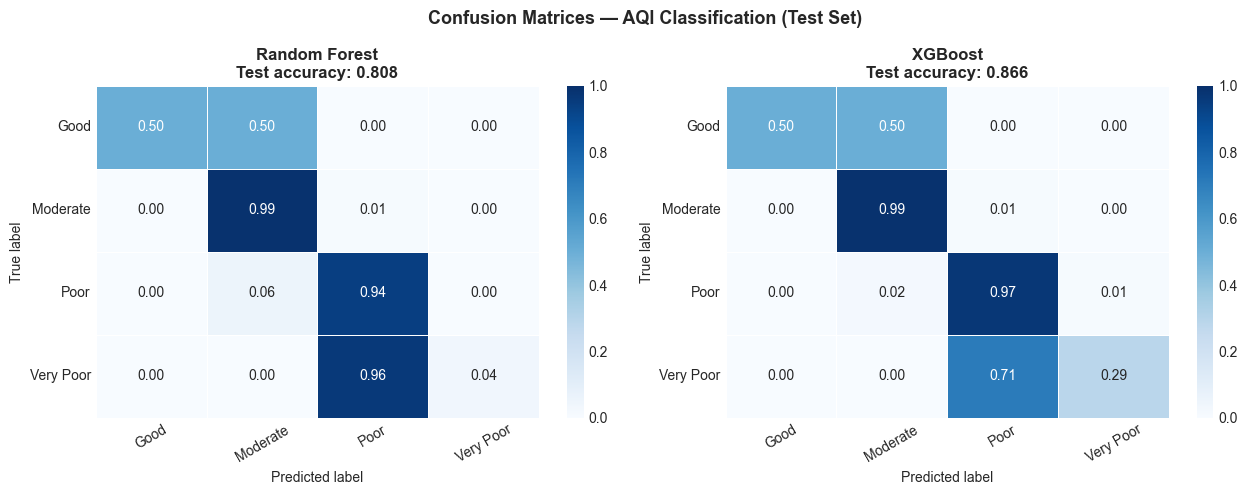


How to read this matrix:
  Rows = true AQI category, Columns = what the model predicted.
  Diagonal (top-left to bottom-right) = correct predictions.
  Off-diagonal values = confusion between classes.
  Value 0.85 in row 'Good', col 'Good' means:
  85% of actual 'Good' hours were correctly classified as 'Good'.


In [8]:
# Plot confusion matrices for both RF and XGB side by side.
# A confusion matrix shows WHAT the model gets wrong — which classes
# it confuses with each other. This is much more informative than
# a single accuracy number.

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, model, name in [
    (axes[0], rf_cls,  "Random Forest"),
    (axes[1], xgb_cls, "XGBoost"),
]:
    y_pred = model.predict(X_test_sc)
    cm = confusion_matrix(y_test_cls, y_pred)
    # confusion_matrix(y_true, y_pred) returns an N×N matrix where
    # cm[i][j] = number of samples with true label i predicted as label j.
    # Diagonal = correct predictions. Off-diagonal = errors.

    # Normalise by row so each row sums to 1 (proportion, not count).
    # This makes classes with fewer samples readable alongside larger classes.
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
    # axis=1 = sum across columns (within each row)
    # keepdims=True keeps the shape (N,1) so division broadcasts correctly

    sns.heatmap(
        cm_norm,
        ax=ax,
        annot=True,           # Write the value in each cell
        fmt=".2f",            # Format as 2 decimal places
        cmap="Blues",         # White → Blue colour scale
        xticklabels=AQI_LABELS,
        yticklabels=AQI_LABELS,
        linewidths=0.5,
        linecolor="white",
        vmin=0, vmax=1        # Fix colour scale 0–1
    )
    acc = accuracy_score(y_test_cls, y_pred)
    ax.set_title(f"{name}\nTest accuracy: {acc:.3f}", fontsize=12, fontweight="bold")
    ax.set_xlabel("Predicted label", fontsize=10)
    ax.set_ylabel("True label", fontsize=10)
    ax.tick_params(axis="x", rotation=30)
    ax.tick_params(axis="y", rotation=0)

plt.suptitle("Confusion Matrices — AQI Classification (Test Set)", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("../outputs/04_confusion_matrices.png", dpi=150, bbox_inches="tight")
plt.show()

print("\nHow to read this matrix:")
print("  Rows = true AQI category, Columns = what the model predicted.")
print("  Diagonal (top-left to bottom-right) = correct predictions.")
print("  Off-diagonal values = confusion between classes.")
print("  Value 0.85 in row 'Good', col 'Good' means:")
print("  85% of actual 'Good' hours were correctly classified as 'Good'.")

---
## Track B — Regression: Predicting NO₂ Concentration

For regression we predict the actual NO₂ value in µg/m³ — a continuous number,
not a category. This is useful for scientists and for generating precise forecasts.

**Key metrics:**
- **RMSE** (Root Mean Squared Error): penalises large errors heavily. In µg/m³.
- **MAE** (Mean Absolute Error): average error magnitude. More interpretable.
- **R²**: fraction of variance explained. R²=0.90 means the model explains
  90% of the variation in NO₂ — the remaining 10% is unexplained noise.

**Note on target leakage:**
We explicitly excluded `NO2(GT)` (the current value) from features in Phase 3.
But we kept `NO2GT_lag_1h`, `NO2GT_lag_24h` etc. — those are PAST values,
not the current value we're trying to predict. This is correct and not leakage.

In [9]:
print("=" * 55)
print("BASELINE REGRESSOR — Dummy (training mean)")
print("=" * 55)

dummy_reg = DummyRegressor(strategy="mean")
# strategy="mean": always predicts the mean of the training targets.
# This gives R²=0 by definition — it's the mathematical zero-baseline.
# Any model with R²>0 explains more variance than just predicting the mean.

dummy_reg.fit(X_train_sc, y_train_reg)

dummy_reg_metrics_val  = evaluate_regressor(dummy_reg, X_val_sc,  y_val_reg,  "Validation")
dummy_reg_metrics_test = evaluate_regressor(dummy_reg, X_test_sc, y_test_reg, "Test")

print(f"\nBaseline always predicts: {dummy_reg.predict([X_train_sc[0]])[0]:.2f} µg/m³")
print(f"(This is the training mean of NO₂)")

BASELINE REGRESSOR — Dummy (training mean)

──────────────────────────────────────────────────
  Validation results
──────────────────────────────────────────────────
  RMSE: 58.9510 µg/m³
  MAE:  47.0432 µg/m³
  R²:   -0.5617

──────────────────────────────────────────────────
  Test results
──────────────────────────────────────────────────
  RMSE: 70.3913 µg/m³
  MAE:  57.6036 µg/m³
  R²:   -1.0940

Baseline always predicts: 96.48 µg/m³
(This is the training mean of NO₂)


In [10]:
print("=" * 55)
print("RANDOM FOREST REGRESSOR")
print("=" * 55)
print("Training...")

rf_reg = RandomForestRegressor(
    n_estimators=200,
    max_depth=20,
    min_samples_leaf=4,
    # Same structural parameters as the classifier.
    # For regression, each leaf outputs the mean of training samples
    # that fall into it (rather than the majority class).

    n_jobs=-1,
    random_state=RANDOM_STATE
    # No class_weight here — regression has no classes.
    # Class imbalance is a classification-only concept.
)

rf_reg.fit(X_train_sc, y_train_reg)
print("Training complete ✓")

rf_reg_metrics_val  = evaluate_regressor(rf_reg, X_val_sc,  y_val_reg,  "Validation")
rf_reg_metrics_test = evaluate_regressor(rf_reg, X_test_sc, y_test_reg, "Test")

RANDOM FOREST REGRESSOR
Training...
Training complete ✓

──────────────────────────────────────────────────
  Validation results
──────────────────────────────────────────────────
  RMSE: 11.6792 µg/m³
  MAE:  6.5192 µg/m³
  R²:   0.9387

──────────────────────────────────────────────────
  Test results
──────────────────────────────────────────────────
  RMSE: 17.1813 µg/m³
  MAE:  10.0228 µg/m³
  R²:   0.8752


In [11]:
print("=" * 55)
print("XGBOOST REGRESSOR")
print("=" * 55)
print("Training...")

xgb_reg = XGBRegressor(
    n_estimators=500,
    # More rounds for regression — we use early_stopping_rounds to prevent
    # overfitting so the extra rounds don't hurt.

    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,

    early_stopping_rounds=30,
    # If the validation score doesn't improve for 30 consecutive rounds,
    # stop training. This prevents overfitting automatically and saves time.
    # The model keeps the best round's weights, not the final round's.

    eval_metric="rmse",
    # Minimise RMSE on the validation set during training.

    n_jobs=-1,
    random_state=RANDOM_STATE,
    verbosity=0
)

xgb_reg.fit(
    X_train_sc, y_train_reg,
    eval_set=[(X_val_sc, y_val_reg)],
    # This is what early_stopping_rounds monitors — it watches validation RMSE.
    verbose=False
)

best_round = xgb_reg.best_iteration
print(f"Training complete ✓  (best round: {best_round} of 500)")

xgb_reg_metrics_val  = evaluate_regressor(xgb_reg, X_val_sc,  y_val_reg,  "Validation")
xgb_reg_metrics_test = evaluate_regressor(xgb_reg, X_test_sc, y_test_reg, "Test")

XGBOOST REGRESSOR
Training...
Training complete ✓  (best round: 214 of 500)

──────────────────────────────────────────────────
  Validation results
──────────────────────────────────────────────────
  RMSE: 10.6062 µg/m³
  MAE:  5.5152 µg/m³
  R²:   0.9494

──────────────────────────────────────────────────
  Test results
──────────────────────────────────────────────────
  RMSE: 16.4927 µg/m³
  MAE:  9.3730 µg/m³
  R²:   0.8850


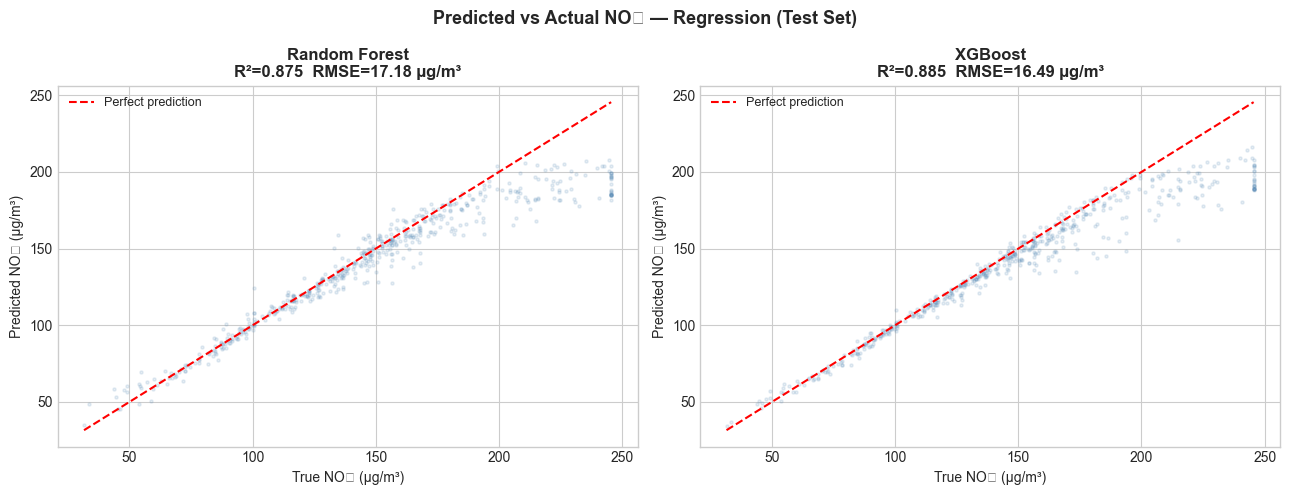

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, model, name in [
    (axes[0], rf_reg,  "Random Forest"),
    (axes[1], xgb_reg, "XGBoost"),
]:
    y_pred = model.predict(X_test_sc)

    # Scatter plot: true value on x-axis, predicted on y-axis.
    # A perfect model would produce all points on the diagonal line y=x.
    # Points above the line = model over-predicted.
    # Points below the line = model under-predicted.
    ax.scatter(
        y_test_reg, y_pred,
        alpha=0.15, s=5,
        color="#5B8DB8",
        rasterized=True
    )

    # Draw the perfect-prediction diagonal line
    min_val = min(y_test_reg.min(), y_pred.min())
    max_val = max(y_test_reg.max(), y_pred.max())
    ax.plot([min_val, max_val], [min_val, max_val],
            "r--", linewidth=1.5, label="Perfect prediction")
    # [min_val, max_val] on both x and y draws the y=x diagonal.

    r2 = r2_score(y_test_reg, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test_reg, y_pred))

    ax.set_title(f"{name}\nR²={r2:.3f}  RMSE={rmse:.2f} µg/m³",
                 fontsize=12, fontweight="bold")
    ax.set_xlabel("True NO₂ (µg/m³)", fontsize=10)
    ax.set_ylabel("Predicted NO₂ (µg/m³)", fontsize=10)
    ax.legend(fontsize=9)

plt.suptitle("Predicted vs Actual NO₂ — Regression (Test Set)", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("../outputs/04_predicted_vs_actual.png", dpi=150, bbox_inches="tight")
plt.show()

MODEL COMPARISON SUMMARY — TEST SET
              Model          track accuracy f1_macro    rmse      r2
        Dummy (cls) Classification   0.6586   0.1985    None    None
Random Forest (cls) Classification   0.8078   0.6250    None    None
      XGBoost (cls) Classification   0.8657   0.7401    None    None
        Dummy (reg)     Regression     None     None 70.3913 -1.0940
Random Forest (reg)     Regression     None     None 17.1813  0.8752
      XGBoost (reg)     Regression     None     None 16.4927  0.8850


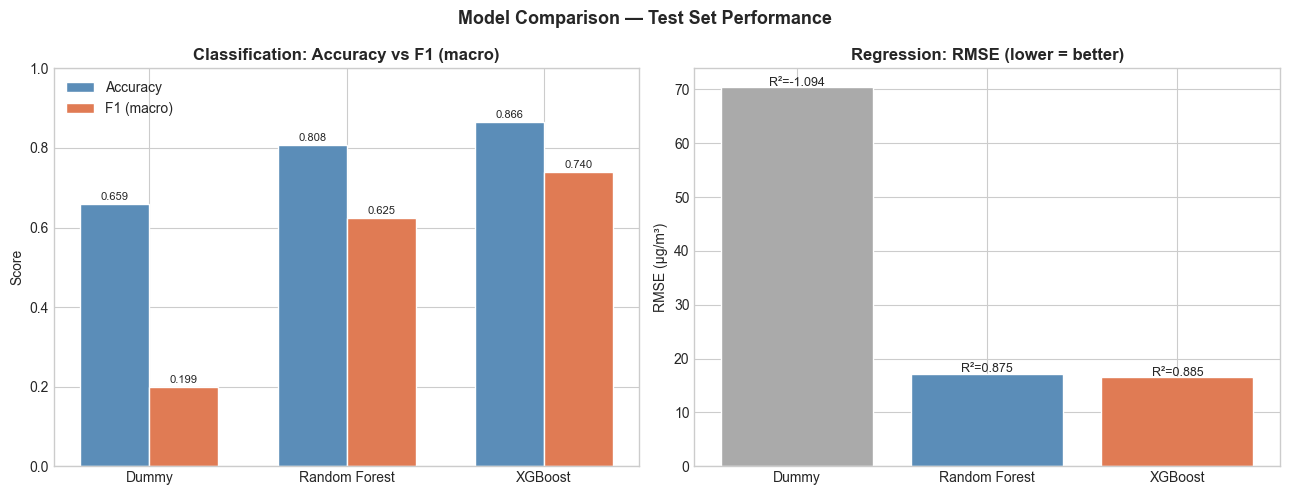

In [13]:
# Build a clean comparison table across all models and both tracks.
# This is the kind of table you show in an interview or portfolio README.

results = {
    # Classification models — evaluated on test set
    "Dummy (cls)":        {"track": "Classification", "accuracy": dummy_cls_metrics_test["accuracy"],
                           "f1_macro": dummy_cls_metrics_test["f1_macro"],   "rmse": None, "r2": None},
    "Random Forest (cls)":{"track": "Classification", "accuracy": rf_cls_metrics_test["accuracy"],
                           "f1_macro": rf_cls_metrics_test["f1_macro"],      "rmse": None, "r2": None},
    "XGBoost (cls)":      {"track": "Classification", "accuracy": xgb_cls_metrics_test["accuracy"],
                           "f1_macro": xgb_cls_metrics_test["f1_macro"],     "rmse": None, "r2": None},

    # Regression models — evaluated on test set
    "Dummy (reg)":        {"track": "Regression",     "accuracy": None, "f1_macro": None,
                           "rmse": dummy_reg_metrics_test["rmse"], "r2": dummy_reg_metrics_test["r2"]},
    "Random Forest (reg)":{"track": "Regression",     "accuracy": None, "f1_macro": None,
                           "rmse": rf_reg_metrics_test["rmse"],    "r2": rf_reg_metrics_test["r2"]},
    "XGBoost (reg)":      {"track": "Regression",     "accuracy": None, "f1_macro": None,
                           "rmse": xgb_reg_metrics_test["rmse"],   "r2": xgb_reg_metrics_test["r2"]},
}

df_results = pd.DataFrame(results).T.reset_index().rename(columns={"index": "Model"})

print("=" * 65)
print("MODEL COMPARISON SUMMARY — TEST SET")
print("=" * 65)
print(df_results.to_string(index=False))

# ── Visual comparison bar chart ───────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Classification: F1 macro
cls_models  = ["Dummy", "Random Forest", "XGBoost"]
cls_f1      = [dummy_cls_metrics_test["f1_macro"],
               rf_cls_metrics_test["f1_macro"],
               xgb_cls_metrics_test["f1_macro"]]
cls_acc     = [dummy_cls_metrics_test["accuracy"],
               rf_cls_metrics_test["accuracy"],
               xgb_cls_metrics_test["accuracy"]]

x = np.arange(len(cls_models))
w = 0.35
axes[0].bar(x - w/2, cls_acc, width=w, label="Accuracy",  color="#5B8DB8", edgecolor="white")
axes[0].bar(x + w/2, cls_f1,  width=w, label="F1 (macro)", color="#E07B54", edgecolor="white")
axes[0].set_xticks(x)
axes[0].set_xticklabels(cls_models)
axes[0].set_ylim(0, 1)
axes[0].set_title("Classification: Accuracy vs F1 (macro)", fontsize=12, fontweight="bold")
axes[0].set_ylabel("Score")
axes[0].legend()
# Annotate bars with values
for rect in axes[0].patches:
    axes[0].text(rect.get_x() + rect.get_width()/2, rect.get_height() + 0.01,
                 f"{rect.get_height():.3f}", ha="center", fontsize=8)

# Regression: RMSE
reg_models = ["Dummy", "Random Forest", "XGBoost"]
reg_rmse   = [dummy_reg_metrics_test["rmse"],
              rf_reg_metrics_test["rmse"],
              xgb_reg_metrics_test["rmse"]]
reg_r2     = [dummy_reg_metrics_test["r2"],
              rf_reg_metrics_test["r2"],
              xgb_reg_metrics_test["r2"]]

color_map = ["#aaaaaa", "#5B8DB8", "#E07B54"]
bars = axes[1].bar(reg_models, reg_rmse, color=color_map, edgecolor="white")
axes[1].set_title("Regression: RMSE (lower = better)", fontsize=12, fontweight="bold")
axes[1].set_ylabel("RMSE (µg/m³)")
for bar, r2 in zip(bars, reg_r2):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                 f"R²={r2:.3f}", ha="center", fontsize=9)

plt.suptitle("Model Comparison — Test Set Performance", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("../outputs/04_model_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

In [14]:
# Save every trained model to disk.
# We save ALL models, not just the best — Phase 5 (SHAP) uses both,
# and it's good practice to have them available for comparison.

models_to_save = {
    "dummy_classifier":      dummy_cls,
    "rf_classifier":         rf_cls,
    "xgb_classifier":        xgb_cls,
    "dummy_regressor":       dummy_reg,
    "rf_regressor":          rf_reg,
    "xgb_regressor":         xgb_reg,
}

for model_name, model_obj in models_to_save.items():
    save_path = f"../models/{model_name}.pkl"
    joblib.dump(model_obj, save_path)
    size_kb = os.path.getsize(save_path) / 1024
    print(f"  Saved: {model_name:<25}  →  {save_path}  ({size_kb:.0f} KB)")

# Also save the best model names so downstream phases know which to load
best_models = {
    "best_classifier": "xgb_classifier",
    "best_regressor":  "xgb_regressor",
}
with open("../models/best_models.json", "w") as f:
    json.dump(best_models, f, indent=2)

print(f"\nAll models saved to models/ ✓")
print(f"Best classifier: {best_models['best_classifier']}")
print(f"Best regressor:  {best_models['best_regressor']}")

  Saved: dummy_classifier           →  ../models/dummy_classifier.pkl  (1 KB)
  Saved: rf_classifier              →  ../models/rf_classifier.pkl  (4359 KB)
  Saved: xgb_classifier             →  ../models/xgb_classifier.pkl  (1678 KB)
  Saved: dummy_regressor            →  ../models/dummy_regressor.pkl  (0 KB)
  Saved: rf_regressor               →  ../models/rf_regressor.pkl  (7608 KB)
  Saved: xgb_regressor              →  ../models/xgb_regressor.pkl  (926 KB)

All models saved to models/ ✓
Best classifier: xgb_classifier
Best regressor:  xgb_regressor


In [15]:
print("=" * 60)
print("PHASE 4 COMPLETE — Modelling Summary")
print("=" * 60)

print(f"""
TRACK A — CLASSIFICATION (Predict AQI Category)
  Baseline accuracy:      {dummy_cls_metrics_test['accuracy']:.3f}
  Random Forest accuracy: {rf_cls_metrics_test['accuracy']:.3f}   F1: {rf_cls_metrics_test['f1_macro']:.3f}
  XGBoost accuracy:       {xgb_cls_metrics_test['accuracy']:.3f}   F1: {xgb_cls_metrics_test['f1_macro']:.3f}
  Improvement over baseline: +{(xgb_cls_metrics_test['accuracy'] - dummy_cls_metrics_test['accuracy']):.3f} accuracy

TRACK B — REGRESSION (Predict NO₂ µg/m³)
  Baseline RMSE:          {dummy_reg_metrics_test['rmse']:.2f}   R²: {dummy_reg_metrics_test['r2']:.3f}
  Random Forest RMSE:     {rf_reg_metrics_test['rmse']:.2f}   R²: {rf_reg_metrics_test['r2']:.3f}
  XGBoost RMSE:           {xgb_reg_metrics_test['rmse']:.2f}   R²: {xgb_reg_metrics_test['r2']:.3f}

MODELS SAVED TO models/
  dummy_classifier.pkl
  rf_classifier.pkl
  xgb_classifier.pkl
  dummy_regressor.pkl
  rf_regressor.pkl
  xgb_regressor.pkl

NEXT: Phase 5 — SHAP interpretability
  We will explain WHY the XGBoost models make each prediction,
  identifying the most important features globally and per-sample.
""")

PHASE 4 COMPLETE — Modelling Summary

TRACK A — CLASSIFICATION (Predict AQI Category)
  Baseline accuracy:      0.659
  Random Forest accuracy: 0.808   F1: 0.625
  XGBoost accuracy:       0.866   F1: 0.740
  Improvement over baseline: +0.207 accuracy

TRACK B — REGRESSION (Predict NO₂ µg/m³)
  Baseline RMSE:          70.39   R²: -1.094
  Random Forest RMSE:     17.18   R²: 0.875
  XGBoost RMSE:           16.49   R²: 0.885

MODELS SAVED TO models/
  dummy_classifier.pkl
  rf_classifier.pkl
  xgb_classifier.pkl
  dummy_regressor.pkl
  rf_regressor.pkl
  xgb_regressor.pkl

NEXT: Phase 5 — SHAP interpretability
  We will explain WHY the XGBoost models make each prediction,
  identifying the most important features globally and per-sample.

